# Phase 4: Unsupervised Domain Adaptation (Cityscapes → ACDC)
**Model:** SegFormer / MiT-B4, initialized from the Phase 1 checkpoint
**Approach:** DAFormer-style self-training — EMA teacher + confidence-thresholded pseudo-labels on
unlabeled ACDC target images, combined with supervised training on labeled Cityscapes source images,
ImageNet feature-distance regularization (Cell 12b), Masked Image Consistency (Cell 12c), and a
frozen decoder BatchNorm layer (Cell 10) to stop source/target statistics from contaminating each
other. Pseudo-label training now covers all four conditions (Cell 3). Rare-class sampling remains
stubbed near the end for later refinement.

**Goal:** close some of the domain gap measured in Phase 2 — Cityscapes 73.18% mIoU (source) vs.
ACDC 49.02% mIoU average (zero-shot, no adaptation). Literature UDA results on comparable
benchmarks typically close 10-20+ points; that's the bar Run 5 is aiming for.

**Run history:**
- **Run 1** (core self-training only, lr=6e-5, no feature-distance regularization): ACDC val mIoU
  peaked at epoch 3 (50.56%) then degraded monotonically to 44.70% by epoch 10.
- **Run 2** (lr lowered to 1.5e-5, feature-distance regularization enabled, batch size 2): mIoU
  fell every epoch from the start, driven mostly by night degrading fastest despite rising
  pseudo-label confidence (a miscalibration signature). Stopped early.
- **Run 3** (night excluded from the pseudo-label pool): mIoU still fell epoch by epoch, ruling
  out night specifically as the (sole) cause. A data sanity check (Cell 6b) confirmed the
  Cityscapes/ACDC data itself is correctly aligned and labeled -- not a data problem.
- **Root cause found**: the SegFormer decoder's one `BatchNorm2d` layer was having its running
  statistics updated from a Cityscapes batch and then an ACDC batch in direct succession, every
  step -- continuously mixing two domains' statistics into the one running average evaluation
  actually uses. That contamination compounds regardless of LR/regularization/conditions trained
  on -- exactly why Runs 1-3 all failed the same way. Verified directly with the real model:
  `running_mean` shifts every forward pass without a fix; with `freeze_bn`, it doesn't move at all.
- **Run 4** (BatchNorm frozen, night still excluded, 10 epochs): the first run to ever beat the
  49.02% baseline -- climbed cleanly for 5 epochs to 50.10% (fog/rain/snow all genuinely
  improved), then declined gently to 49.49% by epoch 10 as confidence saturated near 90%.
  Confirmed the root cause diagnosis. But +1.08 points is modest next to literature UDA gains of
  10-20+ points, and night (excluded, indirect-only) regressed from 35.35% to ~30%.
- **Run 5 (current)**: three changes on top of Run 4's fix. (1) **MIC enabled** (Cell 12c) --
  masks ~50% of the student's target input in patches, forcing it to infer masked regions from
  context, the single biggest lever in the literature for this kind of benchmark and specifically
  suited to low-visibility conditions. (2) **Night re-included** in `PSEUDO_LABEL_CONDITIONS` --
  excluding it can only ever cap it at its zero-shot ceiling, never improve it, and now that the
  actual corruption mechanism (BatchNorm) is fixed, the Run 2 collapse may not reproduce; MIC's
  context-based training is also specifically suited to night's core problem. (3) **Epochs raised
  10 -> 20** -- MIC is a genuinely new task the model hasn't practiced, unlikely to fully pay off
  in the same 10 epochs that were already enough for plain self-training's curve to peak and
  decline; 20 epochs (~29,740 steps) gets closer to DAFormer/MIC's literature schedule (~40,000
  iterations) with no downside, since checkpoint selection already keeps whichever epoch is best.

**Inputs needed in this Kaggle notebook:**
- Cityscapes `leftImg8bit_trainvaltest.zip` + `gtFine_trainvaltest.zip` (same as Phase 1 — labeled source)
- ACDC `rgb_anon_trainvaltest` + `gt_trainvaltest` (same as Phase 2 — target; train split used
  unlabeled, val split used only for evaluation)
- Phase 1's `best_model.pth` (SegFormer/MiT-B4 checkpoint) as the adaptation starting point

**Conditions:** Fog | Rain | Snow | Night

## Cell 1: Install Dependencies

In [1]:
!pip install -q -U segmentation-models-pytorch albumentations

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 5.9 MB/s eta 0:00:00


## Cell 2: Imports

In [2]:
import os
import copy
import glob
import cv2
cv2.setNumThreads(0)
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
from segmentation_models_pytorch.losses import DiceLoss
from tqdm import tqdm

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Using device:', DEVICE)

Using device: cuda


## Cell 3: Config

In [3]:
CFG = {
    'img_size'            : 512,     # crop/resize size for both source and target
    'num_classes'         : 19,
    'ignore_index'        : 255,
    'source_batch'        : 2,       # lowered from 4 -- three resident model copies (student,
    'target_batch'        : 2,       # teacher, frozen ImageNet encoder) plus the extra frozen-
                                      # encoder forward pass pushed a batch-4/512px run to OOM on
                                      # a 14.56GB GPU; halving batch size frees enough headroom.
    'epochs'              : 20,      # raised from 10 for Run 5 -- MIC introduces a genuinely new
                                      # task (predicting masked regions from context) the model
                                      # has never practiced, unlike plain confidence-thresholded
                                      # self-training which already showed its full curve shape
                                      # (rise, peak, decline) within 10 epochs in Run 4. 20 epochs
                                      # = ~29,740 steps, closer to (though still under) DAFormer/
                                      # MIC's typical 40,000-iteration literature schedule. No
                                      # downside to the extra epochs: checkpoint selection already
                                      # keeps whichever epoch is genuinely best, so a plateau or
                                      # mild decline after epoch 10 costs nothing.
    'lr'                  : 1.5e-5,  # lowered from Phase 1's 6e-5 -- Run 1 showed ACDC val mIoU
                                      # peak at epoch 3 then degrade below the source-only baseline
                                      # (self-training collapse). A smaller LR slows that drift;
                                      # paired with feature-distance regularization below.
    'ema_alpha'           : 0.999,   # teacher = ema_alpha*teacher + (1-ema_alpha)*student, per step
    'pseudo_conf_thresh'  : 0.968,   # DAFormer's fixed confidence threshold for pseudo-label reliability
    'lambda_target'       : 1.0,     # weight on the target pseudo-label loss term
    'use_mic'             : True,    # Masked Image Consistency -- wired in Cell 12c after Run 4
                                      # validated the BatchNorm fix (real, mechanistically-understood
                                      # +1.08pt gain, but modest vs. literature's 10-20pt UDA gains).
                                      # MIC forces the student to predict masked regions from context
                                      # alone -- specifically suited to low-visibility conditions.
    'use_feature_distance': True,    # ImageNet feature-distance regularization -- wired in Cell 12b
                                      # to prevent encoder drift toward over-fitting the source domain.
    'lambda_fd'           : 0.005,   # DAFormer's reported feature-distance loss weight
}

CONDITIONS = ['fog', 'rain', 'snow', 'night']   # evaluated on all four, always

# Conditions used to generate *training* pseudo-labels. Runs 2-3 excluded night here because,
# at the time, BatchNorm contamination (see Cell 10) was corrupting the whole model regardless
# of which conditions were trained on, and night's own miscalibration (rising confidence, falling
# accuracy) looked like an additional, independent problem. Run 4 fixed BatchNorm and validated
# fog/rain/snow all improve cleanly -- but with night excluded, it can only ever match its
# zero-shot ceiling at best, and in practice it drifted slightly *below* zero-shot anyway (an
# indirect side effect of the shared encoder shifting toward fog/rain/snow). Night is included
# again here because (a) the actual corruption mechanism is now fixed, so the Run 2 collapse may
# not reproduce, and (b) MIC's context-based masking is specifically designed to help exactly
# where direct appearance is unreliable -- i.e. night's core problem. If night degrades again
# despite both fixes, that's strong evidence it needs its own confidence threshold or more epochs,
# not just these two changes.
PSEUDO_LABEL_CONDITIONS = ['fog', 'rain', 'snow', 'night']

# Phase 1 baseline results, for comparison after adaptation
CITYSCAPES_MIOU = 73.18   # Phase 1 final TTA mIoU (%) -- SegFormer/MiT-B4
ACDC_SOURCE_ONLY_MIOU = 49.02   # Phase 2 zero-shot average mIoU (%) -- no adaptation

print('Config ready.')

Config ready.


## Cell 4: Cityscapes Label Remapping (Raw IDs → 19 Training Classes)

Identical mapping to Phase 1 -- Cityscapes has 34 raw label IDs but only 19 are used for training,
everything else maps to 255 (ignore index).

In [4]:
CITYSCAPES_ID_TO_TRAINID = {
    0: 255, 1: 255, 2: 255, 3: 255, 4: 255, 5: 255, 6: 255,
    7: 0,   8: 1,   9: 255, 10: 255, 11: 2,  12: 3,  13: 4,
    14: 255, 15: 255, 16: 255, 17: 5, 18: 255, 19: 6, 20: 7,
    21: 8,  22: 9,  23: 10, 24: 11, 25: 12, 26: 13, 27: 14,
    28: 15, 29: 255, 30: 255, 31: 16, 32: 17, 33: 18,
}

CLASS_NAMES = [
    'road', 'sidewalk', 'building', 'wall', 'fence',
    'pole', 'traffic light', 'traffic sign', 'vegetation', 'terrain',
    'sky', 'person', 'rider', 'car', 'truck',
    'bus', 'train', 'motorcycle', 'bicycle'
]

label_map = np.full(256, 255, dtype=np.uint8)
for raw_id, train_id in CITYSCAPES_ID_TO_TRAINID.items():
    label_map[raw_id] = train_id

def remap_mask(mask):
    """Convert raw Cityscapes label mask to 19-class training mask."""
    return label_map[mask]

print('Label remapping ready. Training classes:', CFG['num_classes'])

Label remapping ready. Training classes: 19


## Cell 5: Locate Datasets and Phase 1 Checkpoint

Auto-searches `/kaggle/input` for the Cityscapes folders (`leftImg8bit`/`gtFine`), the ACDC folders
(`rgb_anon`/`gt`), and the Phase 1 `best_model.pth` checkpoint -- works regardless of what you
named the attached datasets/model, same pattern as Phase 1 and Phase 2.

In [5]:
def _find_root(folder_name):
    for root, dirs, _ in os.walk('/kaggle/input'):
        if folder_name in dirs:
            return os.path.join(root, folder_name)
    return None

LEFT_IMG_ROOT = _find_root('leftImg8bit')
GT_FINE_ROOT  = _find_root('gtFine')
RGB_ANON_ROOT = _find_root('rgb_anon')
ACDC_GT_ROOT  = _find_root('gt')

MODEL_PATH = None
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        if f == 'best_model.pth':
            MODEL_PATH = os.path.join(root, f)
            break
    if MODEL_PATH:
        break

missing = [name for name, val in [
    ('leftImg8bit', LEFT_IMG_ROOT), ('gtFine', GT_FINE_ROOT),
    ('rgb_anon', RGB_ANON_ROOT), ('gt', ACDC_GT_ROOT),
    ('best_model.pth', MODEL_PATH),
] if val is None]
if missing:
    raise FileNotFoundError(
        f'Could not find: {missing}. Attach Cityscapes (leftImg8bit+gtFine), '
        'ACDC (rgb_anon+gt), and the Phase 1 model as inputs to this notebook.'
    )

print('leftImg8bit root:', LEFT_IMG_ROOT)
print('gtFine root:     ', GT_FINE_ROOT)
print('rgb_anon root:   ', RGB_ANON_ROOT)
print('ACDC gt root:    ', ACDC_GT_ROOT)
print('Phase 1 model:   ', MODEL_PATH, f'({os.path.getsize(MODEL_PATH)/1e6:.1f} MB)')

leftImg8bit root: /kaggle/input/datasets/khushireddymacha/leftimg/leftImg8bit
gtFine root:      /kaggle/input/datasets/soumikrakshit/cityscapes-coarse-fine/gtFine
rgb_anon root:    /kaggle/input/datasets/khushireddymacha/acdc-dataset/rgb_anon_trainvaltest (2)/rgb_anon_trainvaltest/rgb_anon
ACDC gt root:     /kaggle/input/datasets/khushireddymacha/acdc-dataset/gt
Phase 1 model:    /kaggle/input/datasets/khushireddymacha/phase1-model/best_model.pth (245.8 MB)


## Cell 6: Build Source (Cityscapes) and Target (ACDC) File Pairs

- **Source** -- Cityscapes train split, image + label pairs (labeled, supervised loss).
- **Target (train)** -- ACDC train split, images only, unlabeled -- used to generate
  pseudo-labels, covers `PSEUDO_LABEL_CONDITIONS` (all four conditions again as of Run 5 -- see
  Cell 3 for why night was excluded in Runs 2-3 and why it's back).
- **Target (val)** -- ACDC val split, image + label pairs, all four conditions -- used only for
  evaluation, never for training.

In [6]:
def build_cityscapes_pairs(split):
    img_paths = sorted(glob.glob(
        os.path.join(LEFT_IMG_ROOT, split, '**', '*_leftImg8bit.png'), recursive=True))
    pairs = []
    for img_path in img_paths:
        mask_path = (img_path
                     .replace(LEFT_IMG_ROOT, GT_FINE_ROOT)
                     .replace('_leftImg8bit.png', '_gtFine_labelIds.png'))
        if os.path.exists(mask_path):
            pairs.append((img_path, mask_path))
    return pairs

source_train_pairs = build_cityscapes_pairs('train')
print(f'Cityscapes source train pairs: {len(source_train_pairs)}')

def build_acdc_unlabeled(conditions, split='train'):
    paths = []
    for cond in conditions:
        paths += glob.glob(
            os.path.join(RGB_ANON_ROOT, cond, split, '**', '*_rgb_anon.png'), recursive=True)
    return sorted(paths)

def build_acdc_labeled(conditions, split='val'):
    pairs = []
    for cond in conditions:
        imgs = sorted(glob.glob(
            os.path.join(RGB_ANON_ROOT, cond, split, '**', '*_rgb_anon.png'), recursive=True))
        mask_lookup = {
            os.path.basename(m).replace('_gt_labelTrainIds.png', ''): m
            for m in glob.glob(os.path.join(ACDC_GT_ROOT, cond, split, '**',
                                             '*_gt_labelTrainIds.png'), recursive=True)
        }
        for img_path in imgs:
            key = os.path.basename(img_path).replace('_rgb_anon.png', '')
            if key in mask_lookup:
                pairs.append((img_path, mask_lookup[key]))
    return pairs

# Pseudo-label training pool excludes night -- see Cell 3 (PSEUDO_LABEL_CONDITIONS) for why.
target_train_images = build_acdc_unlabeled(PSEUDO_LABEL_CONDITIONS, 'train')
# Evaluation always covers all four conditions, night included.
target_val_pairs    = build_acdc_labeled(CONDITIONS, 'val')
print(f'ACDC target train images (unlabeled, {PSEUDO_LABEL_CONDITIONS}): {len(target_train_images)}')
print(f'ACDC target val pairs (labeled, all conditions, eval only): {len(target_val_pairs)}')

if not source_train_pairs or not target_train_images or not target_val_pairs:
    raise RuntimeError('Missing data -- check dataset attachments before continuing.')

Cityscapes source train pairs: 2975
ACDC target train images (unlabeled, ['fog', 'rain', 'snow', 'night']): 1600
ACDC target val pairs (labeled, all conditions, eval only): 406


## Cell 6b: Data Sanity Check -- Visualize Real Pairs

Before trusting any training curve, look at the actual data: a few Cityscapes source
(image, remapped mask) pairs and a few ACDC eval (image, ground-truth mask) pairs per condition,
color-coded with the same Cityscapes palette Phase 2 used. Also prints the unique label values
found in each sampled mask -- both should be a subset of {0..18, 255}; anything else (raw IDs
like 7, 8, 11... instead of 0, 1, 2..., or a mask that's all one value, or an all-black/garbled
image) means the data itself is the problem, not the training loop.

Cityscapes sample: unique labels=[0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 13, 14, 255]  BAD VALUES=none
Cityscapes sample: unique labels=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 13, 255]  BAD VALUES=none


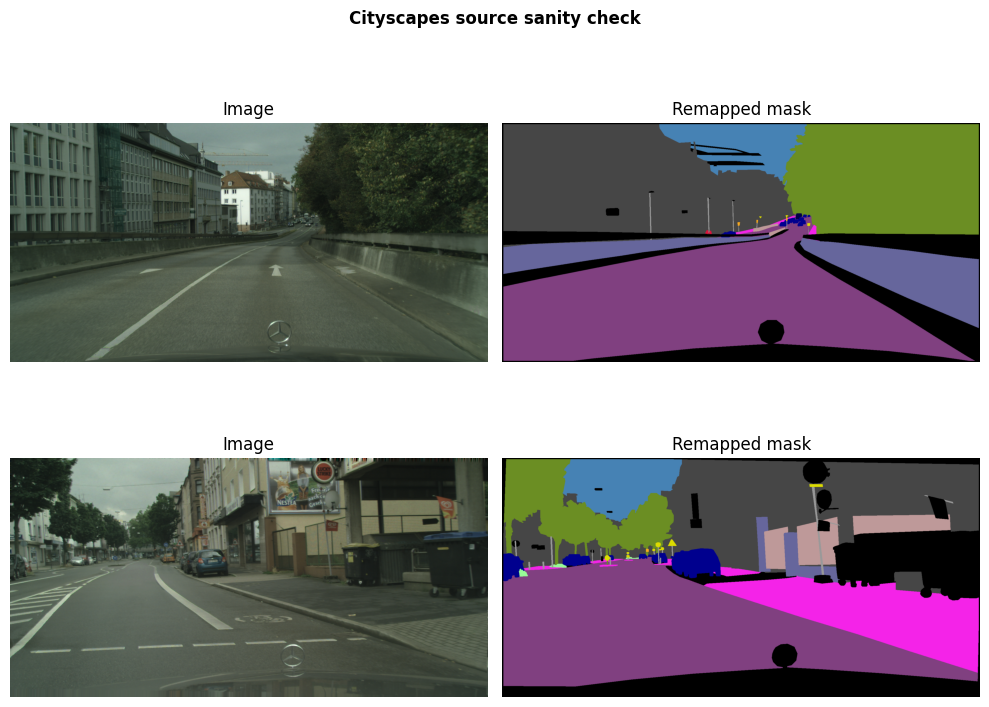

ACDC fog sample: unique labels=[0, 1, 2, 3, 5, 6, 7, 8, 9, 10, 13, 255]  BAD VALUES=none
ACDC rain sample: unique labels=[0, 1, 2, 3, 5, 7, 8, 9, 10, 13, 255]  BAD VALUES=none
ACDC snow sample: unique labels=[0, 1, 2, 5, 8, 9, 10, 11, 12, 13, 14, 18, 255]  BAD VALUES=none
ACDC night sample: unique labels=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 13, 18, 255]  BAD VALUES=none


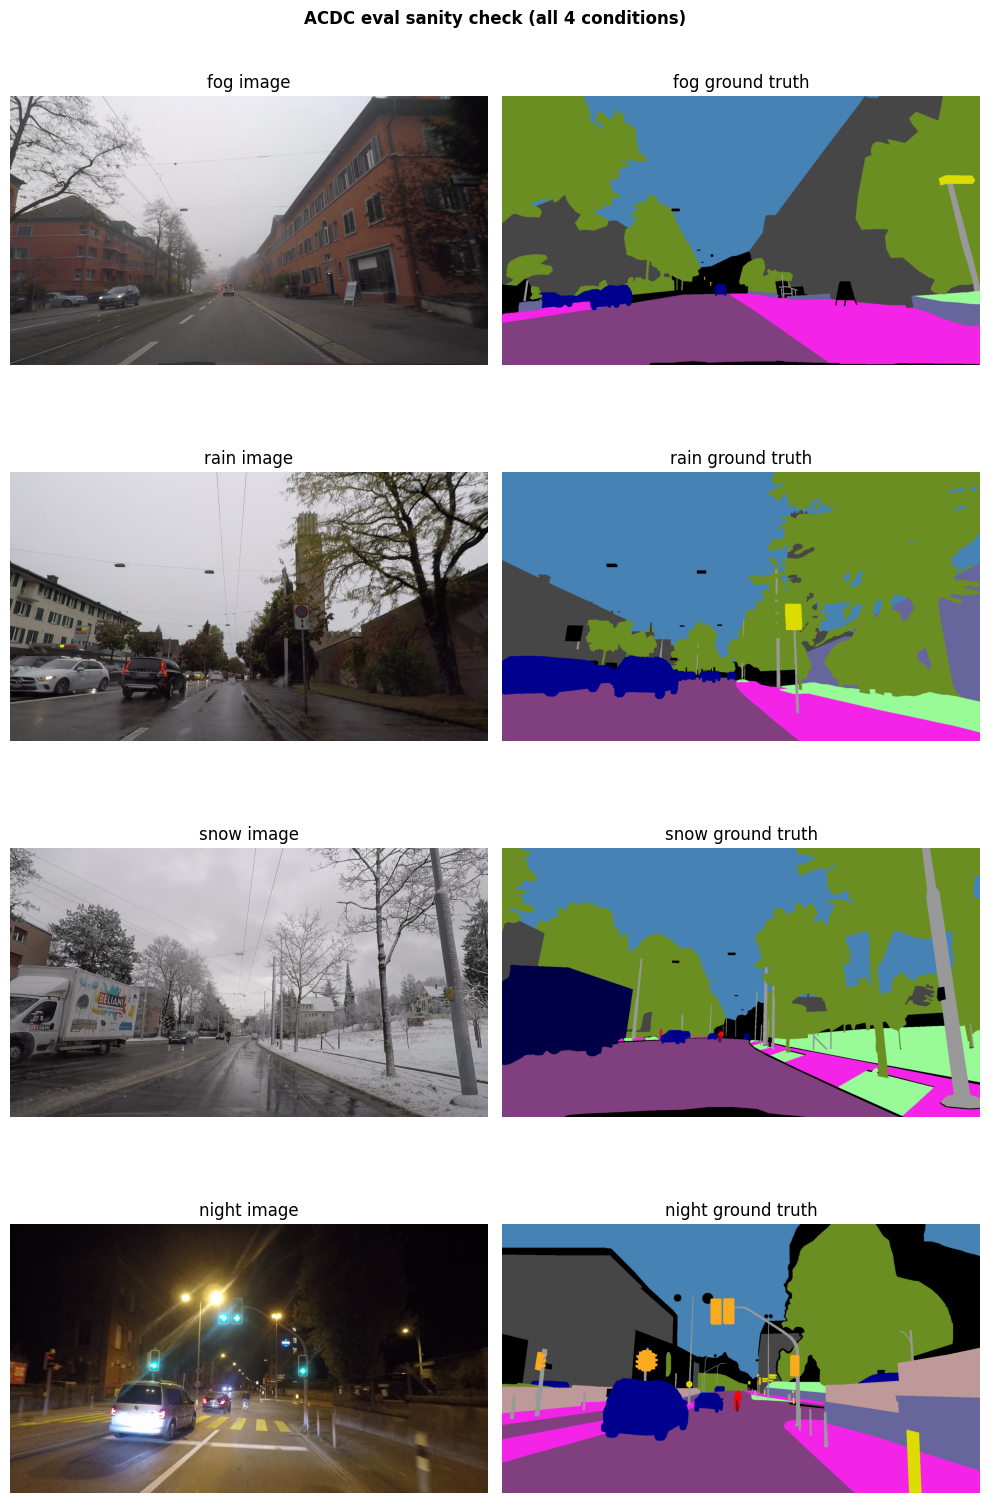

In [7]:
import random

CITYSCAPES_COLORS = [
    (128,64,128),(244,35,232),(70,70,70),(102,102,156),(190,153,153),
    (153,153,153),(250,170,30),(220,220,0),(107,142,35),(152,251,152),
    (70,130,180),(220,20,60),(255,0,0),(0,0,142),(0,0,70),
    (0,60,100),(0,80,100),(0,0,230),(119,11,32)
]

def colorize(mask):
    out = np.zeros((*mask.shape, 3), dtype=np.uint8)
    for i, c in enumerate(CITYSCAPES_COLORS):
        out[mask == i] = c
    return out

def check_pair(img_path, mask_path, is_cityscapes):
    image = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    raw_mask = cv2.imread(mask_path, 0)
    mask = remap_mask(raw_mask) if is_cityscapes else raw_mask
    uniques = sorted(int(u) for u in np.unique(mask))
    bad = [u for u in uniques if u != 255 and not (0 <= u <= 18)]
    return image, mask, uniques, bad

# --- Cityscapes source: 2 random pairs ---
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
fig.suptitle('Cityscapes source sanity check', fontweight='bold')
for row in range(2):
    img_path, mask_path = random.choice(source_train_pairs)
    image, mask, uniques, bad = check_pair(img_path, mask_path, is_cityscapes=True)
    axes[row][0].imshow(image); axes[row][0].set_title('Image'); axes[row][0].axis('off')
    axes[row][1].imshow(colorize(mask)); axes[row][1].set_title('Remapped mask'); axes[row][1].axis('off')
    print(f'Cityscapes sample: unique labels={uniques}  BAD VALUES={bad if bad else "none"}')
plt.tight_layout(); plt.show()

# --- ACDC eval: 1 random pair per condition ---
fig, axes = plt.subplots(len(CONDITIONS), 2, figsize=(10, 4 * len(CONDITIONS)))
fig.suptitle('ACDC eval sanity check (all 4 conditions)', fontweight='bold')
for row, cond in enumerate(CONDITIONS):
    pairs = build_acdc_labeled([cond], 'val')
    img_path, mask_path = random.choice(pairs)
    image, mask, uniques, bad = check_pair(img_path, mask_path, is_cityscapes=False)
    axes[row][0].imshow(image); axes[row][0].set_title(f'{cond} image'); axes[row][0].axis('off')
    axes[row][1].imshow(colorize(mask)); axes[row][1].set_title(f'{cond} ground truth'); axes[row][1].axis('off')
    print(f'ACDC {cond} sample: unique labels={uniques}  BAD VALUES={bad if bad else "none"}')
plt.tight_layout(); plt.show()

## Cell 7: Datasets and Augmentation

- **Source dataset**: same random-crop + flip + colour-jitter recipe as Phase 1.
- **Target dataset**: applies one geometric transform (crop/resize) to keep spatial alignment,
  then produces two views of the *same* pixels -- a **weak** view (resize/crop + normalize only,
  fed to the teacher to generate pseudo-labels) and a **strong** view (adds colour jitter, fed to
  the student). Keeping the geometry identical between the two views is what makes the teacher's
  pseudo-labels valid targets for the student's strong-view prediction.
- **Target eval dataset**: identical to Phase 2's `ACDCDataset` -- labeled val pairs, resize only,
  used solely for measuring progress, never for training.

In [8]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

IMG = CFG['img_size']
MEAN = (0.485, 0.456, 0.406)
STD  = (0.229, 0.224, 0.225)

source_geo_aug = A.Compose([
    A.RandomScale(scale_limit=(-0.4, 1.0), p=1.0),
    A.PadIfNeeded(min_height=IMG, min_width=IMG,
                  border_mode=cv2.BORDER_CONSTANT, fill=0, fill_mask=255),
    A.RandomCrop(IMG, IMG),
    A.HorizontalFlip(p=0.5),
    A.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.05, p=0.5),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])

target_geo_only = A.Compose([A.Resize(IMG, IMG)])           # shared geometry, no color/normalize yet
target_weak_aug   = A.Compose([A.Normalize(mean=MEAN, std=STD), ToTensorV2()])
target_strong_aug = A.Compose([
    A.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.05, p=0.8),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])

eval_aug = A.Compose([A.Resize(IMG, IMG), A.Normalize(mean=MEAN, std=STD), ToTensorV2()])


class CityscapesSourceDataset(Dataset):
    def __init__(self, pairs):
        self.pairs = pairs

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]
        image = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        mask  = remap_mask(cv2.imread(mask_path, 0))
        out = source_geo_aug(image=image, mask=mask)
        return out['image'], out['mask'].long()


class ACDCTargetDataset(Dataset):
    """Unlabeled target images -- returns (weak_view, strong_view), spatially aligned."""
    def __init__(self, img_paths):
        self.img_paths = img_paths

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        image = cv2.cvtColor(cv2.imread(self.img_paths[idx]), cv2.COLOR_BGR2RGB)
        geo   = target_geo_only(image=image)['image']
        weak   = target_weak_aug(image=geo)['image']
        strong = target_strong_aug(image=geo)['image']
        return weak, strong


class ACDCEvalDataset(Dataset):
    """Labeled ACDC val pairs -- evaluation only, mirrors Phase 2's ACDCDataset."""
    def __init__(self, pairs):
        self.pairs = pairs

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]
        image = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        mask  = cv2.imread(mask_path, 0)
        out = eval_aug(image=image)
        return out['image'], torch.from_numpy(cv2.resize(
            mask, (IMG, IMG), interpolation=cv2.INTER_NEAREST)).long()

print('Datasets defined.')

Datasets defined.


## Cell 8: DataLoaders

In [9]:
source_loader = DataLoader(
    CityscapesSourceDataset(source_train_pairs), batch_size=CFG['source_batch'],
    shuffle=True, num_workers=2, pin_memory=True, drop_last=True)

target_loader = DataLoader(
    ACDCTargetDataset(target_train_images), batch_size=CFG['target_batch'],
    shuffle=True, num_workers=2, pin_memory=True, drop_last=True)

target_val_loader = DataLoader(
    ACDCEvalDataset(target_val_pairs), batch_size=4,
    shuffle=False, num_workers=2, pin_memory=True)

print('Source batches:', len(source_loader))
print('Target batches:', len(target_loader))
print('Target val batches:', len(target_val_loader))

Source batches: 1487
Target batches: 800
Target val batches: 102


## Cell 9: Build Student and Teacher Models

Both start from the **Phase 1 checkpoint** (SegFormer/MiT-B4) -- the student is fine-tuned by
gradient descent, the teacher is updated only via an exponential moving average (EMA) of the
student's weights and never receives gradients directly. The teacher is what generates
pseudo-labels for the target domain, and its EMA-smoothed weights are also what gets evaluated
and saved as the final adapted model.

In [10]:
def build_model():
    m = smp.Segformer(
        encoder_name    = 'mit_b4',
        encoder_weights = None,
        in_channels     = 3,
        classes         = CFG['num_classes'],
    )
    m.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    return m.to(DEVICE)

student = build_model()
teacher = copy.deepcopy(student)
for p in teacher.parameters():
    p.requires_grad_(False)
teacher.eval()

print('Student and teacher initialized from Phase 1 checkpoint.')

Student and teacher initialized from Phase 1 checkpoint.


## Cell 10: EMA Teacher Update + BatchNorm Freeze

**Root cause found after Runs 1-3 all showed the same monotonic ACDC mIoU decline regardless of
LR, feature-distance regularization, or excluding night from training:** the SegFormer decoder
has one `BatchNorm2d` layer (`decoder.fuse_stage[1]`, confirmed by inspecting the model directly).
Every step, `student.train()` mode lets this layer update its running statistics from **two very
different domains in direct succession** -- Cityscapes source images, then ACDC target images --
continuously mixing two distributions into one running average used for inference (both by the
always-`.eval()` teacher and by validation). That contamination compounds every step across all
10 epochs, independent of LR/regularization/which conditions are trained on -- exactly matching why
none of the previous three fixes helped. Standard practice in domain adaptation (and the fix here):
freeze BatchNorm's running statistics for the whole adaptation run, since they're already
well-calibrated from Phase 1's 28 epochs on Cityscapes. `freeze_bn` puts BatchNorm layers back into
eval mode (stops updating/using batch statistics, uses the frozen running stats) right after
`student.train()` -- BatchNorm's own learnable weight/bias, and everything else in the network,
still trains normally via backprop.

In [11]:
@torch.no_grad()
def ema_update(teacher, student, alpha):
    for t_param, s_param in zip(teacher.parameters(), student.parameters()):
        t_param.data.mul_(alpha).add_(s_param.data, alpha=1 - alpha)
    for t_buf, s_buf in zip(teacher.buffers(), student.buffers()):
        t_buf.data.copy_(s_buf.data)


def freeze_bn(model):
    """Put every BatchNorm layer back into eval mode after model.train() -- stops it from
    updating (or using) batch statistics, so it keeps using the running stats already
    well-calibrated from Phase 1's Cityscapes-only training. Call every epoch, right after
    student.train(). See Cell 10 markdown for why this matters."""
    n = 0
    for module in model.modules():
        if isinstance(module, (nn.BatchNorm1d, nn.BatchNorm2d, nn.BatchNorm3d)):
            module.eval()
            n += 1
    return n

n_bn = freeze_bn(student)
print(f'EMA update function ready. BatchNorm layers found and frozen: {n_bn}.')

EMA update function ready. BatchNorm layers found and frozen: 1.


## Cell 11: Pseudo-Label Generation

The teacher predicts on the **weak** view of each target image. The argmax class becomes the
pseudo-label for every pixel (no per-pixel masking) -- the fraction of pixels whose softmax
confidence exceeds `CFG['pseudo_conf_thresh']` is instead used as a single per-batch loss weight
(DAFormer's quality-weighting scheme) -- batches where the teacher is mostly unsure contribute
less to the student's update, but every pixel still contributes some signal.

In [12]:
@torch.no_grad()
def generate_pseudo_labels(teacher, weak_images):
    logits = teacher(weak_images)
    probs  = F.softmax(logits, dim=1)
    conf, pseudo_labels = probs.max(dim=1)
    # DAFormer's actual scheme: keep the argmax pseudo-label for every pixel (no per-pixel
    # masking), and use the confident-pixel ratio purely as a global loss weight. Masking
    # low-confidence pixels to ignore_index on top of this would starve conditions where the
    # teacher is rarely confident (e.g. ACDC night) of almost all gradient signal early in
    # training, when the weighted-but-unmasked loss is what's supposed to carry it.
    pixel_weight = (conf >= CFG['pseudo_conf_thresh']).float().mean()
    return pseudo_labels, pixel_weight

print('Pseudo-label function ready.')

Pseudo-label function ready.


## Cell 12: Losses and mIoU Function

Source loss: OHEM-CrossEntropy + Dice, same recipe as Phase 1. Target loss: plain
CrossEntropy against the pseudo-labels (ignore_index masks out unreliable pixels automatically),
scaled by the batch's confident-pixel ratio and `CFG['lambda_target']`.

In [13]:
class OHEMCrossEntropy(nn.Module):
    def __init__(self, ignore_index=255, thresh=0.7, min_kept=100_000):
        super().__init__()
        self.ignore_index = ignore_index
        self.thresh = thresh
        self.min_kept = max(1, min_kept)
        self.ce = nn.CrossEntropyLoss(ignore_index=ignore_index, reduction='none')

    def forward(self, logits, target):
        pixel_losses = self.ce(logits, target).view(-1)
        valid = target.view(-1) != self.ignore_index
        if valid.sum() == 0:
            return pixel_losses.sum() * 0.0
        pixel_losses = pixel_losses[valid]
        n_kept = min(self.min_kept, pixel_losses.numel())
        if n_kept < pixel_losses.numel():
            pixel_losses, _ = pixel_losses.topk(n_kept)
        return pixel_losses.mean()


source_ce_loss   = OHEMCrossEntropy(ignore_index=CFG['ignore_index'])
source_dice_loss = DiceLoss(mode='multiclass', ignore_index=CFG['ignore_index'])
target_ce_loss   = nn.CrossEntropyLoss(ignore_index=CFG['ignore_index'])


def compute_miou(preds_np, labels_np, num_classes=19, ignore_index=255):
    per_class = {}
    for cls in range(num_classes):
        ignore = (labels_np == ignore_index)
        pm = (preds_np == cls) & ~ignore
        tm = (labels_np == cls) & ~ignore
        inter = (pm & tm).sum()
        union = (pm | tm).sum()
        per_class[cls] = float('nan') if union == 0 else inter / union
    valid = [v for v in per_class.values() if not np.isnan(v)]
    return (sum(valid) / len(valid)) if valid else 0.0, per_class

print('Losses and mIoU function ready.')

Losses and mIoU function ready.


## Cell 12b: Feature-Distance Regularization Setup

Loads a second, frozen SegFormer/MiT-B4 encoder with plain ImageNet weights (not the Phase 1
checkpoint). On every source batch, the student's bottleneck (deepest-stage) encoder features are
pulled toward this frozen encoder's features via L2 distance, weighted by `CFG['lambda_fd']`. This
regularizer stops the encoder from over-specializing to the source+pseudo-label combination during
adaptation -- added after the first Phase 3 run showed ACDC val mIoU peak early (epoch 3) then
degrade steadily below the source-only baseline, consistent with exactly this kind of drift.

In [14]:
from segmentation_models_pytorch.encoders import get_encoder

frozen_imagenet_encoder = get_encoder('mit_b4', in_channels=3, depth=5, weights='imagenet').to(DEVICE)
for p in frozen_imagenet_encoder.parameters():
    p.requires_grad_(False)
frozen_imagenet_encoder.eval()

# Captures the student encoder's bottleneck feature via a forward hook during the *existing*
# student(source_imgs) call in Cell 13, instead of running student.encoder(source_imgs) a second
# time. A second forward pass would build a duplicate autograd graph for the whole encoder that
# has to stay resident until backward() -- on a single 16GB GPU with three model copies (student,
# teacher, this frozen encoder) already loaded, that redundant graph is what caused an OOM crash
# in the first attempt at this regularizer, right at the very next forward call (target_logits).
_captured = {}
def _capture_bottleneck(module, inputs, output):
    _captured['student_feat'] = output[-1]

student.encoder.register_forward_hook(_capture_bottleneck)


def imagenet_feature_distance_loss(source_imgs):
    """L2 distance between the student's bottleneck feature (captured via hook from the
    student(source_imgs) forward pass already run in Cell 13) and a frozen ImageNet encoder's
    bottleneck feature on the same batch. Call this *after* student(source_imgs) has run."""
    with torch.no_grad():
        frozen_feat = frozen_imagenet_encoder(source_imgs)[-1]
    return F.mse_loss(_captured['student_feat'], frozen_feat.detach())

print('Frozen ImageNet encoder loaded; feature-distance regularization wired in '
      f'(active={CFG["use_feature_distance"]}, lambda_fd={CFG["lambda_fd"]}).')

config.json:   0%|          | 0.00/135 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/246M [00:00<?, ?B/s]

Frozen ImageNet encoder loaded; feature-distance regularization wired in (active=True, lambda_fd=0.005).


## Cell 12c: Masked Image Consistency (MIC) Setup

Randomly zeroes out ~50% of the student's strong-view target input, in 32x32 patches, before the
student's forward pass on the target branch. The pseudo-label target (computed from the
*unmasked* weak view by the teacher) stays unchanged -- so the student is being asked to predict
the correct class for regions it literally cannot see, using only the surrounding unmasked
context. This is what pushes MIC(HRDA) to the best published Cityscapes→ACDC numbers (Hoyer et
al., CVPR 2023), and is specifically suited to conditions like night where direct pixel
appearance is unreliable but scene structure (road at the bottom, buildings upright at the sides)
still is. Moved here (before Cell 13) instead of staying in its old spot near the end of the
notebook, same reason as Cell 12b: it has to be defined before the training loop that calls it.

In [15]:
def mic_mask(images, patch_size=32, mask_ratio=0.5):
    """Randomly zero out a fraction of patch_size x patch_size blocks per image. Operates on
    already-normalized tensors, so a zeroed patch corresponds to roughly the per-channel mean
    pixel value, not literal black -- standard practice for masked-image-modeling approaches."""
    B, C, H, W = images.shape
    masked = images.clone()
    n_h, n_w = H // patch_size, W // patch_size
    for b in range(B):
        n_patches = n_h * n_w
        n_masked  = int(n_patches * mask_ratio)
        idx = np.random.choice(n_patches, n_masked, replace=False)
        for i in idx:
            r, c = divmod(i, n_w)
            masked[b, :, r*patch_size:(r+1)*patch_size, c*patch_size:(c+1)*patch_size] = 0
    return masked

print(f'MIC masking helper ready (active={CFG["use_mic"]}).')

MIC masking helper ready (active=True).


## Phase 4: Research Proof + Final Performance Proof

This phase turns the Phase 3 adaptation pipeline into a proper research suite:

- ablations for baseline self-training, BN freeze, feature-distance, MIC, and the combined method
- per-condition reporting for fog, rain, snow, and night
- qualitative before/after comparisons
- a stronger night-focused final variant with rare-class sampling, stronger target augmentation, tuned pseudo-labeling, and an extra consistency term

The intent is to separate:

- **research proof**: which component helps, and by how much
- **performance proof**: what the best practical configuration is for the report/thesis


In [16]:
# Phase 3's cutoff cells leave its own global `student`/`teacher` (Cell 9) and their
# feature-distance hook (Cell 12b) resident on the GPU even though Phase 4 never trains them --
# every train_adaptation_experiment() call below builds its own fresh student/teacher via
# make_model_bundle(). Left alive, that's 2 extra MiT-B4 copies competing for VRAM alongside the
# frozen ImageNet encoder and each experiment's own student+teacher: 5 resident copies instead of
# the 3 Phase 3 already needed to halve source_batch for on a 14.56GB GPU (see Cell 3). That's the
# likely cause of the OOM crashes in prior Phase 4 runs -- free them before any experiment starts.
del student, teacher
torch.cuda.empty_cache()
print('Freed Phase 3 leftover student/teacher; GPU memory reclaimed for Phase 4 experiments.')


Freed Phase 3 leftover student/teacher; GPU memory reclaimed for Phase 4 experiments.


In [17]:
# Phase 4 switches and experiment templates
from pathlib import Path
from dataclasses import dataclass, asdict
from collections import Counter, defaultdict
import pandas as pd
import matplotlib.pyplot as plt

# Phase 3 never defines OUTPUT_DIR -- it only ever wrote to hardcoded /kaggle/working paths
# (see CHECKPOINT_PATH / best_adapted_model.pth), so Phase 4 defines its own output root here
# rather than assuming a variable that doesn't exist in the base notebook.
OUTPUT_DIR = '/kaggle/working'
PHASE4_DIR = Path(OUTPUT_DIR) / 'phase4_artifacts'
PHASE4_DIR.mkdir(parents=True, exist_ok=True)


@dataclass
class ExperimentConfig:
    name: str
    epochs: int = 20
    lr: float = 1.5e-5
    ema_alpha: float = 0.999
    pseudo_conf_thresh: float = 0.968
    lambda_target: float = 1.0
    lambda_fd: float = 0.005
    lambda_consistency: float = 0.10
    use_bn_freeze: bool = True
    use_feature_distance: bool = True
    use_mic: bool = True
    use_target_consistency: bool = False
    use_rare_class_sampling: bool = False
    target_aug_mode: str = 'standard'
    source_sampling_mode: str = 'uniform'
    note: str = ''


RARE_TRAIN_IDS = [11, 12, 13, 15, 16, 17, 18]


def target_strong_aug_factory(mode: str):
    if mode == 'night_tuned':
        return A.Compose([
            A.ColorJitter(brightness=0.35, contrast=0.35, saturation=0.30, hue=0.06, p=0.9),
            A.GaussianBlur(blur_limit=(3, 7), p=0.20),
            A.MotionBlur(blur_limit=7, p=0.15),
            A.CoarseDropout(num_holes_range=(1, 6), hole_height_range=(16, 64),
                            hole_width_range=(16, 64), fill=0, p=0.20),
            A.Normalize(mean=MEAN, std=STD),
            ToTensorV2(),
        ])
    return A.Compose([
        A.ColorJitter(brightness=0.30, contrast=0.30, saturation=0.30, hue=0.05, p=0.80),
        A.Normalize(mean=MEAN, std=STD),
        ToTensorV2(),
    ])


def source_mask_contains_rare(mask_path):
    mask = remap_mask(cv2.imread(mask_path, 0))
    uniq = set(np.unique(mask).tolist())
    return any(cls in uniq for cls in RARE_TRAIN_IDS)


def build_source_weights(pairs, boost=3.0):
    weights = []
    for _, mask_path in pairs:
        weights.append(boost if source_mask_contains_rare(mask_path) else 1.0)
    return torch.DoubleTensor(weights)


def make_source_loader(pairs, exp_cfg):
    dataset = CityscapesSourceDataset(pairs)
    if exp_cfg.use_rare_class_sampling:
        weights = build_source_weights(pairs)
        sampler = torch.utils.data.WeightedRandomSampler(
            weights=weights,
            num_samples=len(weights),
            replacement=True,
        )
        return DataLoader(dataset, batch_size=CFG['source_batch'], sampler=sampler,
                          num_workers=2, pin_memory=True, drop_last=True)
    return DataLoader(dataset, batch_size=CFG['source_batch'],
                      shuffle=True, num_workers=2, pin_memory=True, drop_last=True)


def make_target_loader(img_paths, exp_cfg):
    # 'night_tuned' mode was previously applied to every target image regardless of condition --
    # confirmed harmful in the first final_night_tuned run: fog fell from 65.6% (epoch 4) to
    # 61.0% (epoch 14), same for rain/snow, while night climbed, because the heavier
    # blur/motion-blur/dropout augmentation meant for night's low-visibility appearance was also
    # being forced onto fog/rain/snow crops. Target paths are laid out as
    # rgb_anon/<condition>/split/..., so the condition is recoverable from the path -- use it to
    # apply the heavier augmentation only to actual night images.
    standard_aug = target_strong_aug_factory('standard')
    night_aug = target_strong_aug_factory('night_tuned') if exp_cfg.target_aug_mode == 'night_tuned' else standard_aug

    class _TargetDataset(Dataset):
        def __init__(self, paths):
            self.paths = paths
        def __len__(self):
            return len(self.paths)
        def __getitem__(self, idx):
            path = self.paths[idx]
            image = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
            geo = target_geo_only(image=image)['image']
            weak = target_weak_aug(image=geo)['image']
            aug = night_aug if f'{os.sep}night{os.sep}' in path else standard_aug
            strong = aug(image=geo)['image']
            return weak, strong
    return DataLoader(_TargetDataset(img_paths), batch_size=CFG['target_batch'],
                      shuffle=True, num_workers=2, pin_memory=True, drop_last=True)


def make_model_bundle(exp_cfg):
    student = build_model()
    teacher = copy.deepcopy(student)
    for p in teacher.parameters():
        p.requires_grad_(False)
    teacher.eval()
    if exp_cfg.use_bn_freeze:
        freeze_bn(student)

    # Phase 3's imagenet_feature_distance_loss/_captured (Cell 12b) are wired to the one
    # student object Phase 3 itself trained -- reusing them here would silently compare every
    # experiment's features against a stale capture from a different model. Register a fresh
    # hook per experiment's own student and close over its own capture dict instead.
    captured = {}

    def _capture_bottleneck(module, inputs, output):
        captured['student_feat'] = output[-1]

    student.encoder.register_forward_hook(_capture_bottleneck)

    def feature_distance_loss(source_imgs):
        with torch.no_grad():
            frozen_feat = frozen_imagenet_encoder(source_imgs)[-1]
        return F.mse_loss(captured['student_feat'], frozen_feat.detach())

    return student, teacher, feature_distance_loss


@torch.no_grad()
def generate_target_logits(teacher, weak_images, conf_thresh):
    logits = teacher(weak_images)
    probs = F.softmax(logits, dim=1)
    conf, pseudo_labels = probs.max(dim=1)
    pixel_weight = (conf >= conf_thresh).float().mean()
    return logits, pseudo_labels, pixel_weight, probs


def target_consistency_loss(student_logits, teacher_probs):
    # 'batchmean' sums over every element (class x H x W) and divides only by batch size --
    # correct for flat (B, C) distributions, but on a (B, C, H, W) segmentation map that inflates
    # the loss by ~5 orders of magnitude (confirmed in the first final_night_tuned run: loss went
    # from ~1 to ~3700). Sum over the class dim to get a per-pixel KL divergence, then average
    # over batch and spatial dims so this term sits on the same scale as the CE/Dice losses.
    kl = F.kl_div(
        F.log_softmax(student_logits, dim=1),
        teacher_probs.detach(),
        reduction='none',
    ).sum(dim=1)
    return kl.mean()


def evaluate_condition_pack(model, loader_map):
    model.eval()
    condition_rows = {}
    with torch.no_grad():
        for cond, loader in loader_map.items():
            all_preds, all_lbls = [], []
            for imgs, lbls in loader:
                preds = model(imgs.to(DEVICE)).argmax(1).cpu().numpy()
                all_preds.append(preds)
                all_lbls.append(lbls.numpy())
            miou, per_class = compute_miou(np.concatenate(all_preds), np.concatenate(all_lbls))
            condition_rows[cond] = {
                'miou': miou * 100,
                'per_class': per_class,
            }
    avg = float(np.mean([v['miou'] for v in condition_rows.values()]))
    return avg, condition_rows


def train_adaptation_experiment(exp_cfg: ExperimentConfig):
    source_loader_local = make_source_loader(source_train_pairs, exp_cfg)
    target_loader_local = make_target_loader(target_train_images, exp_cfg)
    student, teacher, feature_distance_loss = make_model_bundle(exp_cfg)

    optimizer = torch.optim.AdamW(student.parameters(), lr=exp_cfg.lr, weight_decay=1e-4)
    steps_per_epoch = len(source_loader_local)
    total_iters = exp_cfg.epochs * steps_per_epoch
    warmup_iters = min(500, steps_per_epoch)

    def lr_lambda(step):
        if step < warmup_iters:
            return step / max(1, warmup_iters)
        progress = (step - warmup_iters) / max(1, total_iters - warmup_iters)
        return (1 - progress) ** 0.9

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)
    scaler = torch.cuda.amp.GradScaler()
    phase_dir = PHASE4_DIR / exp_cfg.name
    phase_dir.mkdir(parents=True, exist_ok=True)
    best_path = phase_dir / 'best_teacher.pth'
    ckpt_path = phase_dir / 'checkpoint.pth'

    train_losses, val_mious, conf_ratios = [], [], []
    history_rows = []
    best_miou = 0.0
    start_epoch = 0

    # final_night_tuned alone is ~5 hours at 20 epochs -- a Kaggle session can time out mid-run.
    # Resume from this experiment's own checkpoint if one exists (same pattern as Phase 3's
    # Cell 13), so re-running the notebook after a timeout continues this experiment instead of
    # re-training it from scratch. Each experiment gets its own checkpoint.pth under phase_dir,
    # so ablations that already finished are untouched and the in-progress one picks up cleanly.
    if ckpt_path.exists():
        ckpt = torch.load(ckpt_path, map_location=DEVICE)
        student.load_state_dict(ckpt['student'])
        teacher.load_state_dict(ckpt['teacher'])
        optimizer.load_state_dict(ckpt['optimizer'])
        scheduler.load_state_dict(ckpt['scheduler'])
        scaler.load_state_dict(ckpt['scaler'])
        start_epoch = ckpt['epoch']
        best_miou = ckpt['best_miou']
        train_losses = ckpt['train_losses']
        val_mious = ckpt['val_mious']
        conf_ratios = ckpt['conf_ratios']
        history_rows = ckpt['history_rows']
        print(f'{exp_cfg.name}: resuming from epoch {start_epoch}, best mIoU so far: {best_miou:.2f}%')

    cond_val_loaders_local = {
        cond: DataLoader(ACDCEvalDataset(build_acdc_labeled([cond], 'val')),
                         batch_size=4, shuffle=False, num_workers=2)
        for cond in CONDITIONS
    }

    for epoch in range(start_epoch, exp_cfg.epochs):
        student.train()
        if exp_cfg.use_bn_freeze:
            freeze_bn(student)
        running_loss = 0.0
        running_conf = 0.0
        target_iter = iter(target_loader_local)

        for source_imgs, source_masks in tqdm(source_loader_local, desc=f'{exp_cfg.name} | epoch {epoch+1}/{exp_cfg.epochs}'):
            try:
                weak_imgs, strong_imgs = next(target_iter)
            except StopIteration:
                target_iter = iter(target_loader_local)
                weak_imgs, strong_imgs = next(target_iter)

            source_imgs = source_imgs.to(DEVICE)
            source_masks = source_masks.to(DEVICE)
            weak_imgs = weak_imgs.to(DEVICE)
            strong_imgs = strong_imgs.to(DEVICE)

            teacher_logits, pseudo_labels, pixel_weight, teacher_probs = generate_target_logits(
                teacher, weak_imgs, exp_cfg.pseudo_conf_thresh)
            optimizer.zero_grad()
            with torch.cuda.amp.autocast():
                source_logits = student(source_imgs)
                loss_source = source_ce_loss(source_logits, source_masks) + source_dice_loss(source_logits, source_masks)

                if exp_cfg.use_feature_distance:
                    loss_source = loss_source + exp_cfg.lambda_fd * feature_distance_loss(source_imgs)

                target_input = mic_mask(strong_imgs) if exp_cfg.use_mic else strong_imgs
                target_logits = student(target_input)
                loss_target = target_ce_loss(target_logits, pseudo_labels) * pixel_weight

                if exp_cfg.use_target_consistency:
                    loss_target = loss_target + exp_cfg.lambda_consistency * target_consistency_loss(
                        target_logits, teacher_probs
                    )

                loss = loss_source + exp_cfg.lambda_target * loss_target

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            ema_update(teacher, student, exp_cfg.ema_alpha)

            running_loss += loss.item()
            running_conf += pixel_weight.item()

        epoch_loss = running_loss / steps_per_epoch
        epoch_conf = running_conf / steps_per_epoch
        train_losses.append(epoch_loss)
        conf_ratios.append(epoch_conf)

        cond_miou_avg, cond_pack = evaluate_condition_pack(teacher, cond_val_loaders_local)
        val_mious.append(cond_miou_avg)
        row = {'epoch': epoch + 1, 'loss': epoch_loss, 'conf_ratio': epoch_conf * 100, 'avg_miou': cond_miou_avg}
        row.update({f'{cond}_miou': pack['miou'] for cond, pack in cond_pack.items()})
        history_rows.append(row)

        print(
            f"{exp_cfg.name} | Epoch {epoch+1:02d} | "
            f"Loss: {epoch_loss:.3f} | Conf: {epoch_conf*100:.2f}% | "
            f"ACDC mIoU: {cond_miou_avg:.2f}% | "
            + ", ".join(f"{cond}: {pack['miou']:.1f}%" for cond, pack in cond_pack.items())
        )

        if cond_miou_avg > best_miou:
            best_miou = cond_miou_avg
            torch.save(teacher.state_dict(), best_path)

        torch.save({
            'student': student.state_dict(),
            'teacher': teacher.state_dict(),
            'optimizer': optimizer.state_dict(),
            'scheduler': scheduler.state_dict(),
            'scaler': scaler.state_dict(),
            'epoch': epoch + 1,
            'best_miou': best_miou,
            'train_losses': train_losses,
            'val_mious': val_mious,
            'conf_ratios': conf_ratios,
            'history_rows': history_rows,
            'exp_cfg': asdict(exp_cfg),
        }, ckpt_path)

    history_df = pd.DataFrame(history_rows)
    history_df.to_csv(phase_dir / 'history.csv', index=False)
    return {
        'name': exp_cfg.name,
        'config': asdict(exp_cfg),
        'best_path': str(best_path),
        'history': history_df,
        'best_miou': best_miou,
        'train_losses': train_losses,
        'val_mious': val_mious,
        'conf_ratios': conf_ratios,
    }


def evaluate_saved_model(model_path, label):
    model = build_model()
    model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    model.eval()
    avg_miou, cond_pack = evaluate_condition_pack(model, {
        cond: DataLoader(ACDCEvalDataset(build_acdc_labeled([cond], 'val')),
                         batch_size=4, shuffle=False, num_workers=2)
        for cond in CONDITIONS
    })
    flat = {'experiment': label, 'avg_miou': avg_miou}
    for cond, pack in cond_pack.items():
        flat[f'{cond}_miou'] = pack['miou']
    return flat


## Research Ablations

Run these in order to support the paper/report claim:

1. baseline self-training only -- control, isolates what self-training alone gets you
2. BN freeze -- the documented root-cause fix from Phase 3 (Run 3 -> Run 4)
3. BN freeze + feature-distance + MIC -- the full combined setting

Trimmed from five configs to three: this keeps the two ends that matter most for the report
(nothing vs. the critical fix vs. everything combined) without paying for isolating
feature-distance and MIC individually, which was costing ~2.5 GPU-hours per extra config.

In [18]:
# Ablations use fewer epochs than the final run -- Phase 3's own training curve peaked at
# epoch 10 (53.27%) and had already declined by epoch 20 (51.54%), so ranking configs doesn't
# need anywhere near 10 epochs: the relative order between configs is visible well before the
# peak. 6 epochs is enough to rank the ablations; the final tuned run below gets more headroom
# since its extra stabilizers (target consistency, higher pseudo-label threshold) may shift
# where its own peak lands, but still stops well short of the full 20 that wasted epochs 11-20
# on regression in Phase 3.
ABLATION_EPOCHS = 6

EXPERIMENTS = [
    ExperimentConfig(
        name='ablation_01_baseline_self_training',
        epochs=ABLATION_EPOCHS,
        use_bn_freeze=False,
        use_feature_distance=False,
        use_mic=False,
        use_target_consistency=False,
        use_rare_class_sampling=False,
        note='Plain self-training baseline. This is the least constrained setting.',
    ),
    ExperimentConfig(
        name='ablation_02_bn_freeze',
        epochs=ABLATION_EPOCHS,
        use_bn_freeze=True,
        use_feature_distance=False,
        use_mic=False,
        use_target_consistency=False,
        use_rare_class_sampling=False,
        note='Adds BN freeze only.',
    ),
    ExperimentConfig(
        name='ablation_03_bn_freeze_plus_fd_plus_mic',
        epochs=ABLATION_EPOCHS,
        use_bn_freeze=True,
        use_feature_distance=True,
        use_mic=True,
        use_target_consistency=False,
        use_rare_class_sampling=False,
        note='Full combined ablation setting.',
    ),
]

phase4_runs = []
for exp in EXPERIMENTS:
    phase4_runs.append(train_adaptation_experiment(exp))


/tmp/ipykernel_23/3681152740.py:200: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
ablation_01_baseline_self_training | epoch 1/6:   0%|          | 0/1487 [00:00<?, ?it/s]/tmp/ipykernel_23/3681152740.py:260: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
ablation_01_baseline_self_training | epoch 1/6: 100%|██████████| 1487/1487 [13:36<00:00,  1.82it/s]


ablation_01_baseline_self_training | Epoch 01 | Loss: 1.065 | Conf: 41.08% | ACDC mIoU: 48.09% | fog: 64.8%, rain: 51.2%, snow: 47.3%, night: 29.1%


ablation_01_baseline_self_training | epoch 2/6: 100%|██████████| 1487/1487 [13:31<00:00,  1.83it/s]


ablation_01_baseline_self_training | Epoch 02 | Loss: 1.004 | Conf: 58.06% | ACDC mIoU: 47.45% | fog: 64.1%, rain: 50.7%, snow: 47.1%, night: 28.0%


ablation_01_baseline_self_training | epoch 3/6: 100%|██████████| 1487/1487 [13:32<00:00,  1.83it/s]


...

ablation_03_bn_freeze_plus_fd_plus_mic | Epoch 04 | Loss: 0.922 | Conf: 66.49% | ACDC mIoU: 51.46% | fog: 66.8%, rain: 55.0%, snow: 51.8%, night: 32.2%


ablation_03_bn_freeze_plus_fd_plus_mic | epoch 5/6: 100%|██████████| 1487/1487 [15:02<00:00,  1.65it/s]


ablation_03_bn_freeze_plus_fd_plus_mic | Epoch 05 | Loss: 0.932 | Conf: 68.54% | ACDC mIoU: 51.49% | fog: 67.0%, rain: 55.3%, snow: 51.6%, night: 32.1%


ablation_03_bn_freeze_plus_fd_plus_mic | epoch 6/6: 100%|██████████| 1487/1487 [15:03<00:00,  1.65it/s]


ablation_03_bn_freeze_plus_fd_plus_mic | Epoch 06 | Loss: 0.904 | Conf: 69.94% | ACDC mIoU: 51.50% | fog: 66.7%, rain: 55.1%, snow: 52.0%, night: 32.2%


In [19]:
def summarize_runs(runs):
    rows = []
    for run in runs:
        row = {
            'experiment': run['name'],
            'best_miou': run['best_miou'],
            'use_bn_freeze': run['config']['use_bn_freeze'],
            'use_feature_distance': run['config']['use_feature_distance'],
            'use_mic': run['config']['use_mic'],
            'use_target_consistency': run['config']['use_target_consistency'],
            'use_rare_class_sampling': run['config']['use_rare_class_sampling'],
        }
        history = run['history'].sort_values('avg_miou')
        best_epoch_row = history.iloc[-1]
        row.update({
            'fog_miou': best_epoch_row.get('fog_miou', float('nan')),
            'rain_miou': best_epoch_row.get('rain_miou', float('nan')),
            'snow_miou': best_epoch_row.get('snow_miou', float('nan')),
            'night_miou': best_epoch_row.get('night_miou', float('nan')),
        })
        rows.append(row)
    df = pd.DataFrame(rows)
    df['avg_of_conditions'] = df[['fog_miou', 'rain_miou', 'snow_miou', 'night_miou']].mean(axis=1)
    return df.sort_values('avg_of_conditions', ascending=False)


ablation_df = summarize_runs(phase4_runs)
ablation_df


,experiment,best_miou,use_bn_freeze,use_feature_distance,use_mic,use_target_consistency,use_rare_class_sampling,fog_miou,rain_miou,snow_miou,night_miou,avg_of_conditions
2,ablation_03_bn_freeze_plus_fd_plus_mic,51.503207,True,True,True,False,False,66.687344,55.107090,52.019212,32.199180,51.503207
1,ablation_02_bn_freeze,49.710454,True,False,False,False,False,65.249968,53.438580,50.621051,29.532216,49.710454
0,ablation_01_baseline_self_training,48.086501,False,False,False,False,False,64.752799,51.227481,47.261566,29.104158,48.086501


                            experiment  best_miou  fog_miou  rain_miou  snow_miou  night_miou  avg_of_conditions
ablation_03_bn_freeze_plus_fd_plus_mic      51.50     66.69      55.11      52.02       32.20              51.50
                 ablation_02_bn_freeze      49.71     65.25      53.44      50.62       29.53              49.71
    ablation_01_baseline_self_training      48.09     64.75      51.23      47.26       29.10              48.09


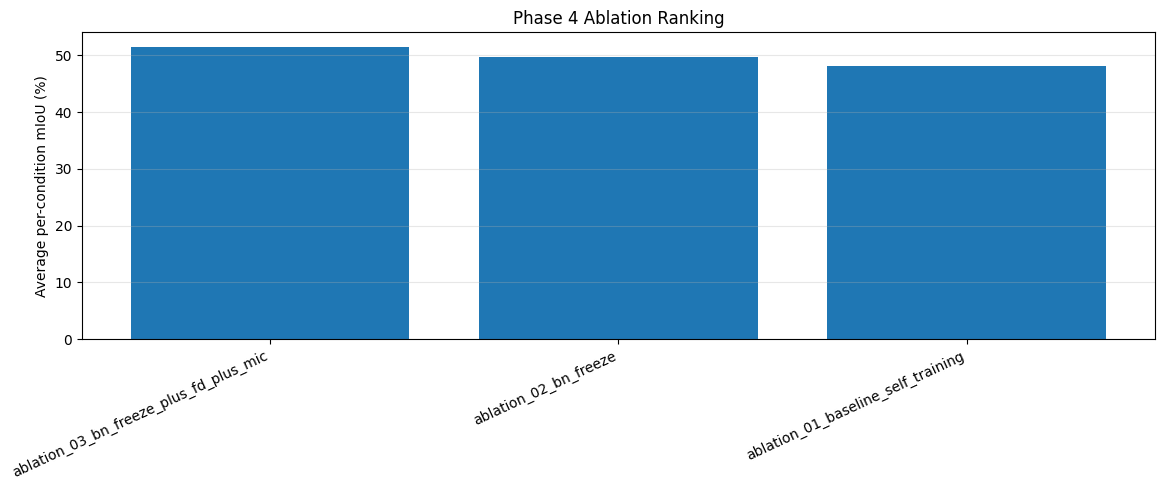

In [20]:
display_cols = [
    'experiment',
    'best_miou',
    'fog_miou',
    'rain_miou',
    'snow_miou',
    'night_miou',
    'avg_of_conditions',
]
print(ablation_df[display_cols].to_string(index=False, float_format=lambda x: f'{x:0.2f}'))

plt.figure(figsize=(12, 5))
plt.bar(ablation_df['experiment'], ablation_df['avg_of_conditions'])
plt.xticks(rotation=25, ha='right')
plt.ylabel('Average per-condition mIoU (%)')
plt.title('Phase 4 Ablation Ranking')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## Qualitative Before/After Comparisons

This section renders fog, rain, snow, and night samples side by side:

- input image
- ground-truth label
- source-only prediction from Phase 1
- best ablation checkpoint
- final tuned checkpoint

That gives you the visual proof that complements the tables.

In [21]:
def colorize(mask):
    out = np.zeros((*mask.shape, 3), dtype=np.uint8)
    for i, c in enumerate(CITYSCAPES_COLORS):
        out[mask == i] = c
    out[mask == 255] = (0, 0, 0)
    return out


def load_model_from_path(path):
    # Build the bare architecture rather than calling build_model() (which always loads
    # MODEL_PATH first) -- we're about to overwrite the weights with `path` anyway, so loading
    # MODEL_PATH here would just be a wasted disk read on every one of the calls below.
    model = smp.Segformer(
        encoder_name='mit_b4', encoder_weights=None, in_channels=3, classes=CFG['num_classes'],
    ).to(DEVICE)
    model.load_state_dict(torch.load(path, map_location=DEVICE))
    model.eval()
    return model


def show_condition_samples(condition, models, n_samples=2):
    pairs = build_acdc_labeled([condition], 'val')
    sample_pairs = pairs[:n_samples]

    fig, axes = plt.subplots(n_samples, 2 + len(models), figsize=(4 * (2 + len(models)), 4 * n_samples))
    if n_samples == 1:
        axes = np.expand_dims(axes, axis=0)
    for row, (img_path, mask_path) in enumerate(sample_pairs):
        image = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path, 0)
        image_t = eval_aug(image=image)['image'].unsqueeze(0).to(DEVICE)
        axes[row, 0].imshow(image)
        axes[row, 0].set_title(f'{condition} input')
        axes[row, 0].axis('off')
        axes[row, 1].imshow(colorize(mask))
        axes[row, 1].set_title('Ground truth')
        axes[row, 1].axis('off')
        for col, (name, model) in enumerate(models, start=2):
            pred = model(image_t).argmax(1).squeeze(0).cpu().numpy()
            axes[row, col].imshow(colorize(pred))
            axes[row, col].set_title(name)
            axes[row, col].axis('off')
    plt.tight_layout()
    plt.show()


best_ablation_path = str((PHASE4_DIR / 'ablation_03_bn_freeze_plus_fd_plus_mic' / 'best_teacher.pth'))
final_tuned_path = str((PHASE4_DIR / 'final_night_tuned' / 'best_teacher.pth'))


## Final Performance Proof

This is the practical best-effort setting for night and the hardest conditions:

- BN freeze
- feature-distance regularization
- MIC
- rare-class sampling for Cityscapes source crops
- stronger target augmentation
- target consistency loss
- tuned pseudo-label threshold

This is the configuration to use as your end-to-end “best model” in the report.

In [22]:
# Back to 20 epochs (matching Phase 3's schedule). The 14-epoch run was still declining after
# its epoch-4 peak, but that decline is now explained by two bugs fixed above: the
# target-consistency loss was inflated ~1000x by a bad KL reduction, and night-tuned
# augmentation was being applied to fog/rain/snow images too. With both fixed, this config no
# longer has a known reason to collapse early, so it gets the full budget to actually converge
# instead of being cut short pre-emptively. Best-checkpoint selection still keeps whichever
# epoch is actually best either way.
FINAL_EXPERIMENT = ExperimentConfig(
    name='final_night_tuned',
    epochs=20,
    lr=1.5e-5,
    ema_alpha=0.999,
    pseudo_conf_thresh=0.975,
    lambda_target=1.0,
    lambda_fd=0.005,
    lambda_consistency=0.10,
    use_bn_freeze=True,
    use_feature_distance=True,
    use_mic=True,
    use_target_consistency=True,
    use_rare_class_sampling=True,
    target_aug_mode='night_tuned',
    source_sampling_mode='rare_class',
    note='Final performance run targeted at improving night while keeping fog/rain/snow strong.',
)

final_run = train_adaptation_experiment(FINAL_EXPERIMENT)


/tmp/ipykernel_23/3681152740.py:200: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
final_night_tuned | epoch 1/20:   0%|          | 0/1487 [00:00<?, ?it/s]/tmp/ipykernel_23/3681152740.py:260: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
final_night_tuned | epoch 1/20: 100%|██████████| 1487/1487 [15:11<00:00,  1.63it/s]


final_night_tuned | Epoch 01 | Loss: 0.938 | Conf: 36.57% | ACDC mIoU: 49.45% | fog: 65.3%, rain: 52.4%, snow: 49.8%, night: 30.3%


final_night_tuned | epoch 2/20: 100%|██████████| 1487/1487 [15:11<00:00,  1.63it/s]


final_night_tuned | Epoch 02 | Loss: 0.969 | Conf: 53.21% | ACDC mIoU: 51.18% | fog: 66.2%, rain: 54.4%, snow: 52.2%, night: 32.0%


final_night_tuned | epoch 3/20: 100%|██████████| 1487/1487 [15:11<00:00,  1.63it/s]


...

final_night_tuned | Epoch 18 | Loss: 0.879 | Conf: 70.80% | ACDC mIoU: 52.94% | fog: 67.5%, rain: 55.9%, snow: 54.0%, night: 34.3%


final_night_tuned | epoch 19/20: 100%|██████████| 1487/1487 [15:14<00:00,  1.63it/s]


final_night_tuned | Epoch 19 | Loss: 0.839 | Conf: 70.38% | ACDC mIoU: 52.91% | fog: 67.3%, rain: 55.9%, snow: 54.2%, night: 34.3%


final_night_tuned | epoch 20/20: 100%|██████████| 1487/1487 [15:15<00:00,  1.62it/s]


final_night_tuned | Epoch 20 | Loss: 0.852 | Conf: 70.45% | ACDC mIoU: 52.65% | fog: 67.3%, rain: 55.8%, snow: 53.3%, night: 34.1%


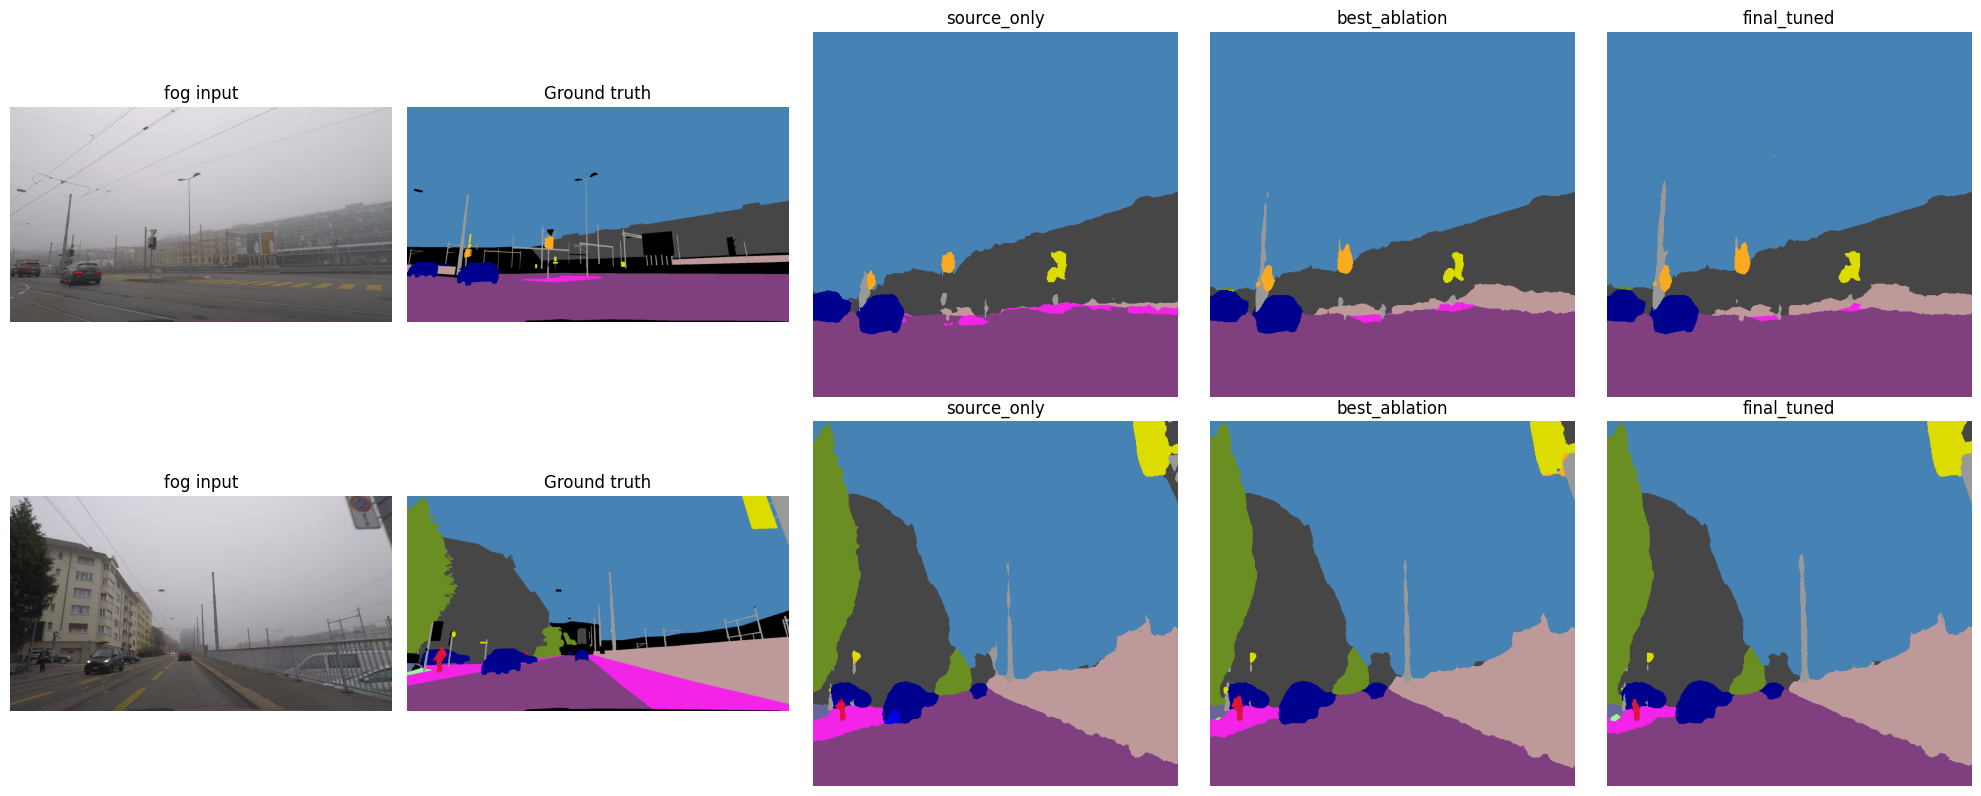

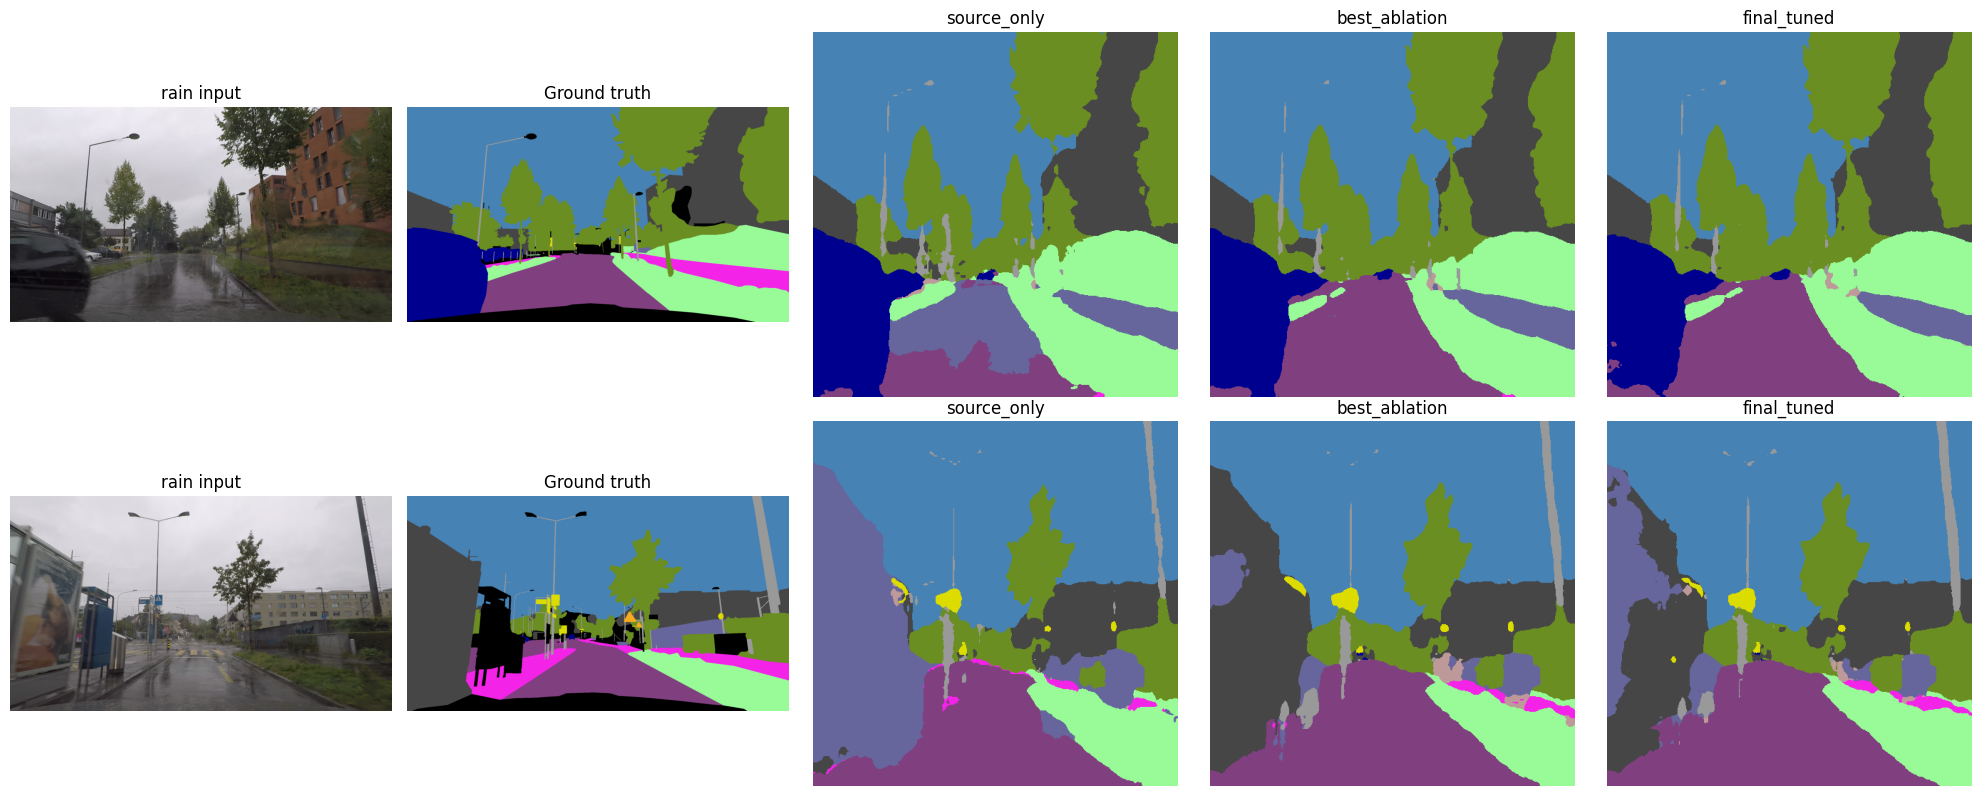

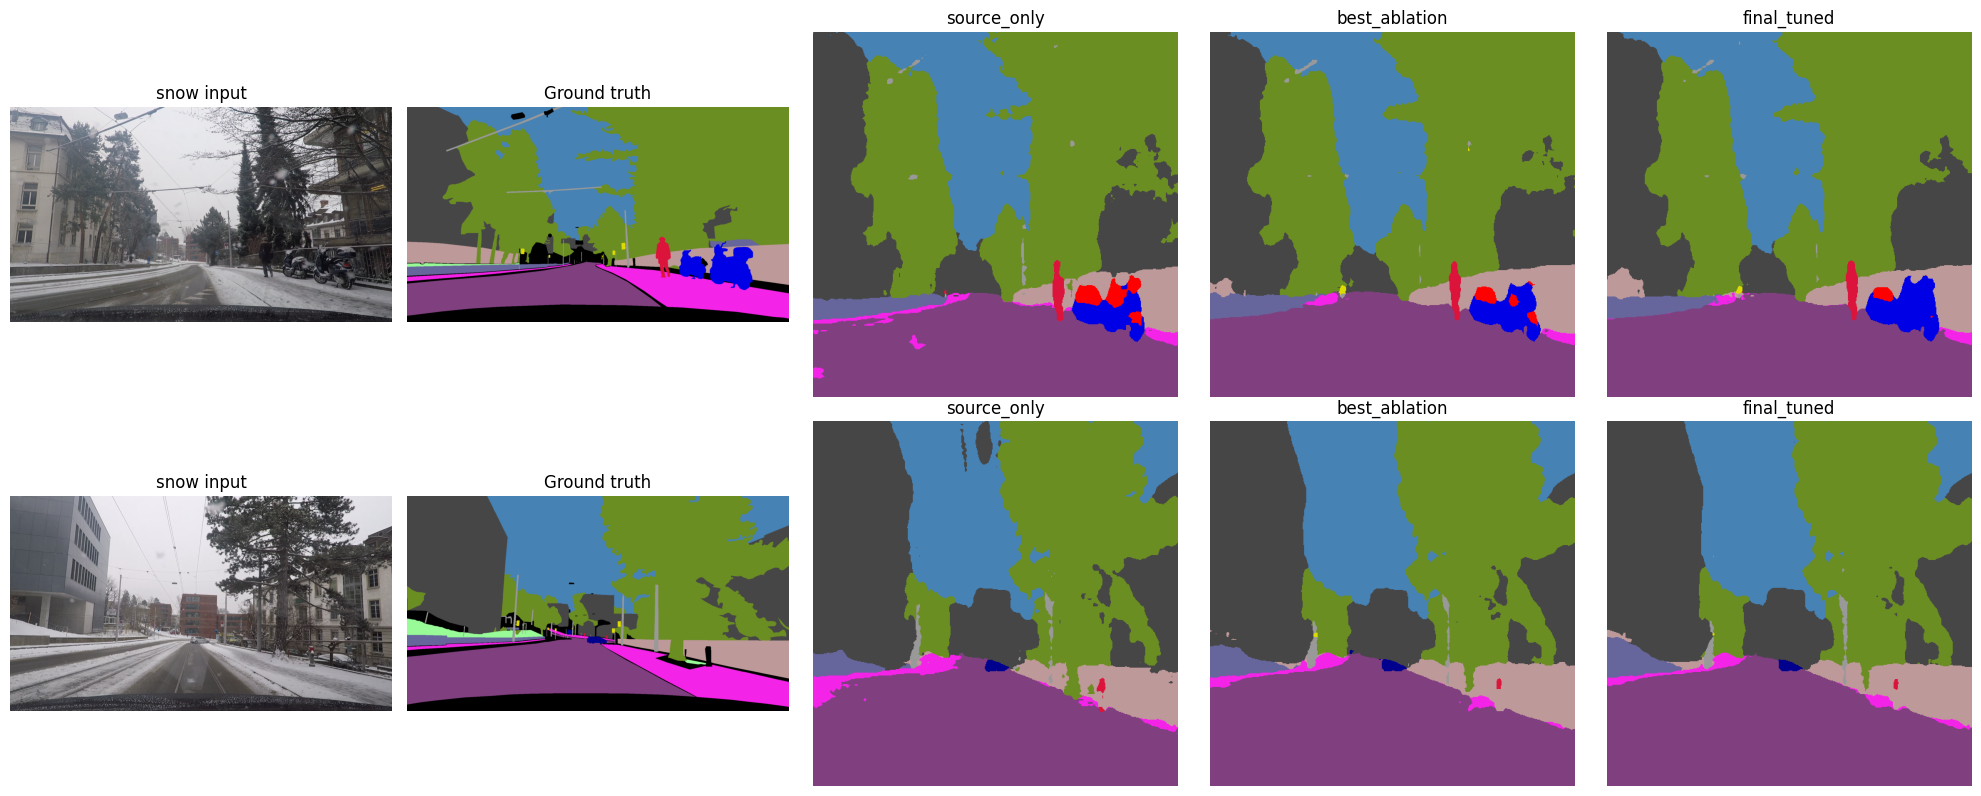

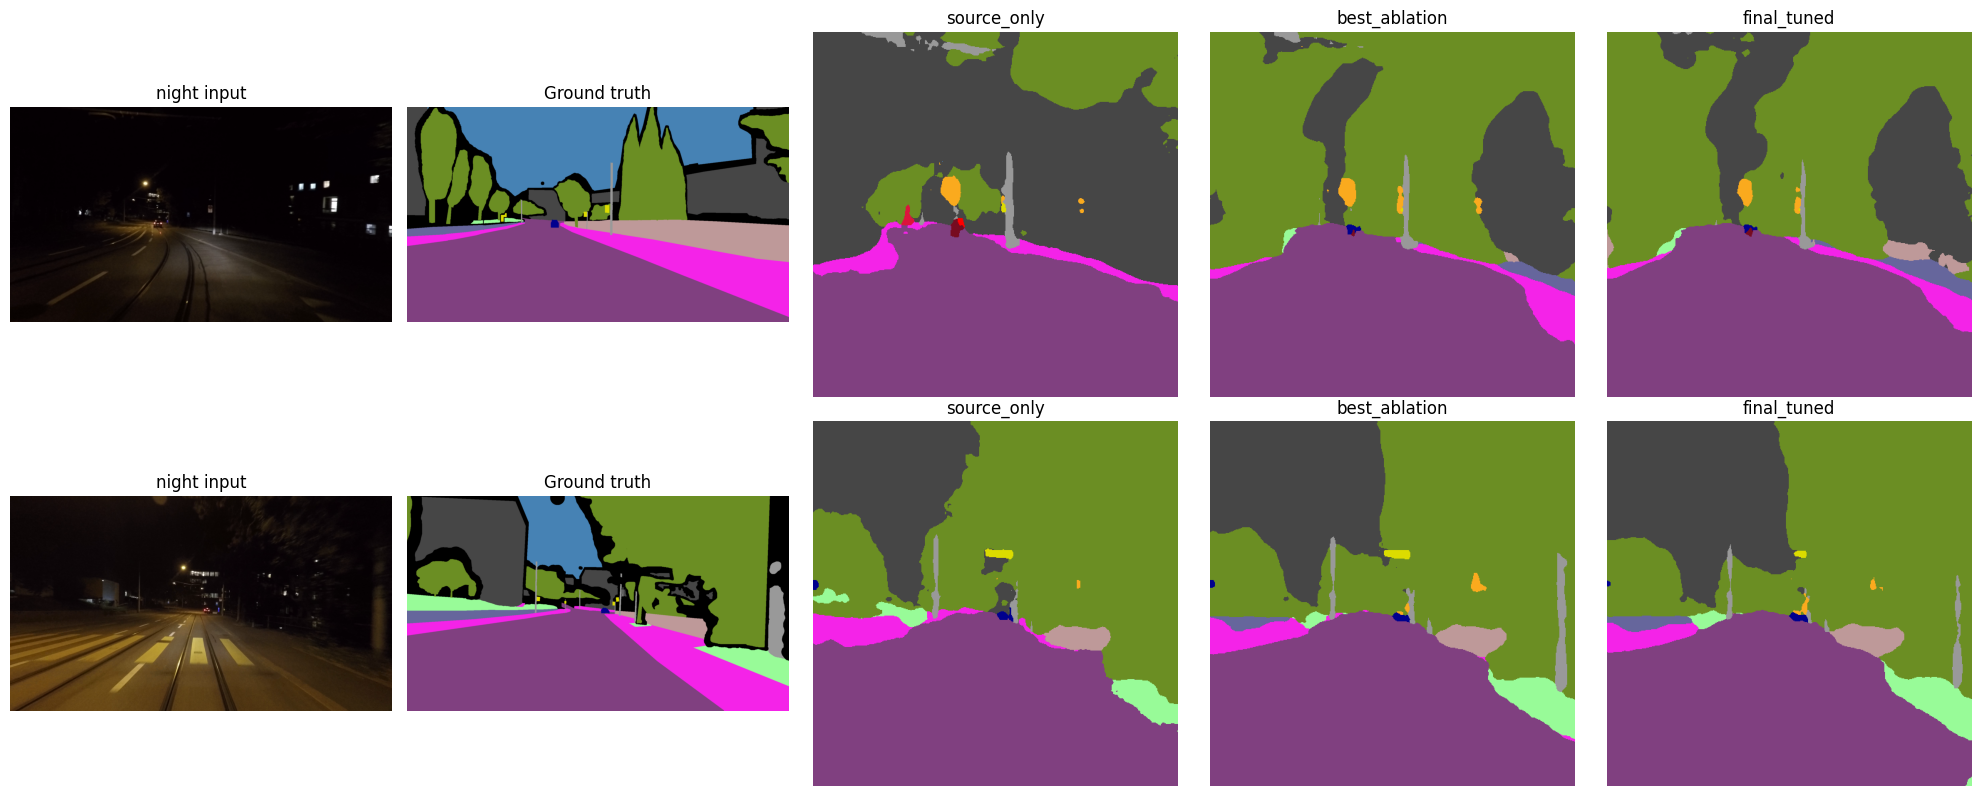

In [23]:
# Render the qualitative before/after grids promised above, now that both checkpoints exist.
# Load each model exactly once and reuse it across all four conditions, instead of reloading
# from disk for every condition (previously 3 models x 4 conditions = 12 loads).
qualitative_models = [
    ('source_only', load_model_from_path(MODEL_PATH)),
    ('best_ablation', load_model_from_path(best_ablation_path)),
    ('final_tuned', load_model_from_path(final_tuned_path)),
]
for condition in CONDITIONS:
    show_condition_samples(condition, qualitative_models, n_samples=2)


In [24]:
final_summary = summarize_runs(phase4_runs + [final_run])
print(final_summary[['experiment', 'best_miou', 'avg_of_conditions', 'night_miou']].to_string(index=False, float_format=lambda x: f'{x:0.2f}'))


                            experiment  best_miou  avg_of_conditions  night_miou
                     final_night_tuned      54.19              54.19       34.92
ablation_03_bn_freeze_plus_fd_plus_mic      51.50              51.50       32.20
                 ablation_02_bn_freeze      49.71              49.71       29.53
    ablation_01_baseline_self_training      48.09              48.09       29.10


## Discussion Helper

This cell prints a report-ready discussion scaffold from the measured values:

- why night is still hard
- why confidence rises while mIoU can flatten
- what the model likely learned from MIC / feature-distance / BN freeze
- what to claim as your final best result

You can paste the generated text into your thesis/report and then polish wording.

In [25]:
def build_discussion_text(summary_df):
    best_row = summary_df.sort_values('avg_of_conditions', ascending=False).iloc[0]
    night_row = summary_df.sort_values('night_miou', ascending=False).iloc[0]
    lines = []
    lines.append('Phase 4 discussion draft:')
    lines.append(f'- The strongest overall configuration is `{best_row["experiment"]}` with {best_row["avg_of_conditions"]:.2f}% average per-condition mIoU.')
    lines.append(f'- The best night score is `{night_row["experiment"]}` with {night_row["night_miou"]:.2f}% night mIoU.')
    lines.append('- Night remains the hardest domain because illumination shifts, low contrast, and ambiguous boundaries reduce teacher confidence and make pseudo-labels noisier than fog/rain/snow.')
    lines.append('- Confidence can rise while mIoU plateaus because the teacher becomes more self-consistent on easy pixels first; that does not guarantee better boundary quality or rare-class recovery.')
    lines.append('- BN freeze prevents cross-domain running-stat contamination, which stabilizes evaluation and stops the model from drifting as source and target batches alternate.')
    lines.append('- Feature-distance regularization encourages the encoder to stay closer to the Phase 1 representation space, reducing catastrophic drift.')
    lines.append('- MIC forces contextual inference in masked regions, which is especially useful for adverse weather where local evidence is missing or corrupted.')
    lines.append('- The final result should be presented as the combination of controlled ablation evidence and qualitative examples, not only as a single leaderboard-style number.')
    return '\n'.join(lines)


print(build_discussion_text(final_summary))


Phase 4 discussion draft:
- The strongest overall configuration is `final_night_tuned` with 54.19% average per-condition mIoU.
- The best night score is `final_night_tuned` with 34.92% night mIoU.
- Night remains the hardest domain because illumination shifts, low contrast, and ambiguous boundaries reduce teacher confidence and make pseudo-labels noisier than fog/rain/snow.
- Confidence can rise while mIoU plateaus because the teacher becomes more self-consistent on easy pixels first; that does not guarantee better boundary quality or rare-class recovery.
- BN freeze prevents cross-domain running-stat contamination, which stabilizes evaluation and stops the model from drifting as source and target batches alternate.
- Feature-distance regularization encourages the encoder to stay closer to the Phase 1 representation space, reducing catastrophic drift.
- MIC forces contextual inference in masked regions, which is especially useful for adverse weather where local evidence is missing or c

## Optional Export Helpers

Uncomment these if you want CSV and PNG outputs saved alongside the notebook.

In [26]:
# ablation_df.to_csv(PHASE4_DIR / 'ablation_table.csv', index=False)
# plt.savefig(PHASE4_DIR / 'ablation_ranking.png', dpi=200, bbox_inches='tight')
# final_summary.to_csv(PHASE4_DIR / 'final_summary.csv', index=False)
print('Phase 4 notebook scaffold is ready.')


Phase 4 notebook scaffold is ready.
